In [44]:
import numpy as np
import agama
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
from reverse_orbit import reverse_orbit
agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Solar mass

In [45]:
pot_mw = agama.Potential(
    dict(type='Dehnen', mass=1.0e10, scaleRadius=1.0, gamma=1),       # Bulge
    dict(type='MiyamotoNagai', mass=5.0e10, scaleRadius=3.0, scaleHeight=0.3),  # Disk
    dict(type='NFW', mass=2e12, scaleRadius=22.0))                     # Dark matter halo

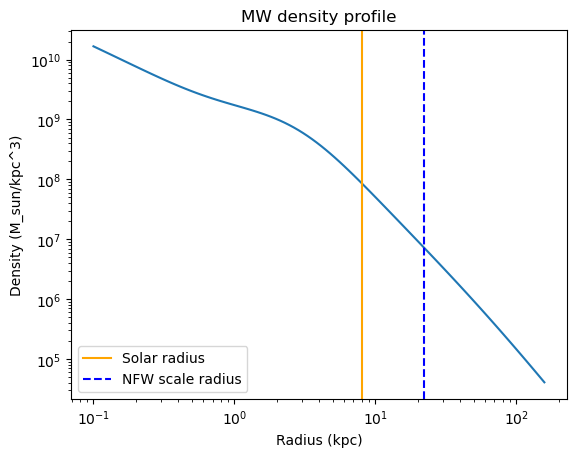

In [46]:
# Non-essential: MW density profile
r_array = np.logspace(-1, 2.2, 100)
pts = np.column_stack((r_array, np.zeros_like(r_array), np.zeros_like(r_array)))
rho_mw = pot_mw.density(pts)

plt.figure()
plt.loglog(r_array, rho_mw)
plt.axvline(8.0, color='orange', label='Solar radius')
plt.axvline(22.0, color='b', linestyle='--', label='NFW scale radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M_sun/kpc^3)')
plt.title('MW density profile')
plt.legend()
plt.show()

In [51]:
mc_mass0 = 1e-6  # Solar masses
mc_rvir  = 1e-5  # virial radius [kpc]
mc_rs    = 1e-6   # scale radius [kpc]
Nbody    = 1000

In [52]:
pot_mc = agama.Potential(
    type='spheroid', gamma=1, beta=3,
    scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)

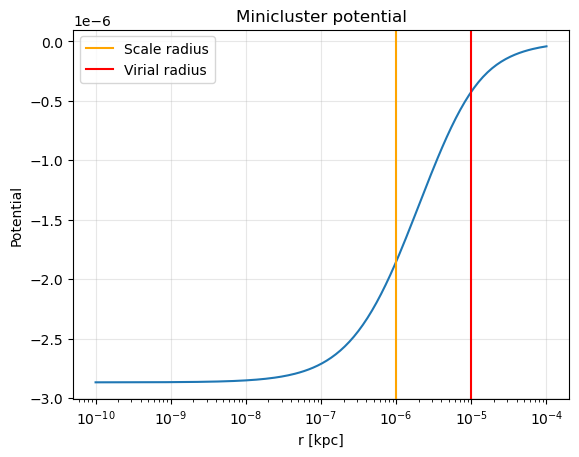

In [53]:
r = np.logspace(-10, -4, 200)  # adjust range to your units
pts = np.column_stack((r, np.zeros_like(r), np.zeros_like(r)))

plt.figure()
plt.semilogx(r, pot_mc.potential(pts))
plt.xlabel('r [kpc]')
plt.ylabel('Potential')
plt.title('Minicluster potential')
plt.axvline(mc_rs, color='orange', label='Scale radius')
plt.axvline(mc_rvir, color='r', label='Virial radius')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


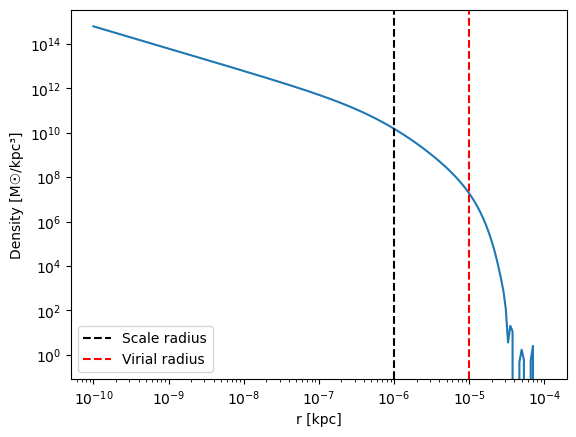

In [54]:
plt.figure()
plt.loglog(r, pot_mc.density(pts))
plt.xlabel('r [kpc]')
plt.ylabel('Density [M☉/kpc³]')
plt.axvline(mc_rs,   color='k', linestyle='--', label='Scale radius')
plt.axvline(mc_rvir, color='r', linestyle='--', label='Virial radius')
plt.legend()
plt.show()


In [55]:
#distribution function for mc is initialised, limit 1e-6kpc, PROBLEMATIC.
df_mc   = agama.DistributionFunction(type='quasispherical', potential=pot_mc)
mc_mass0 = pot_mc.totalMass()  # exact mass after cutoff

In [56]:
#particles are sampled from the distribution function, with positions and velocities.
mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc, df_mc).sample(Nbody)


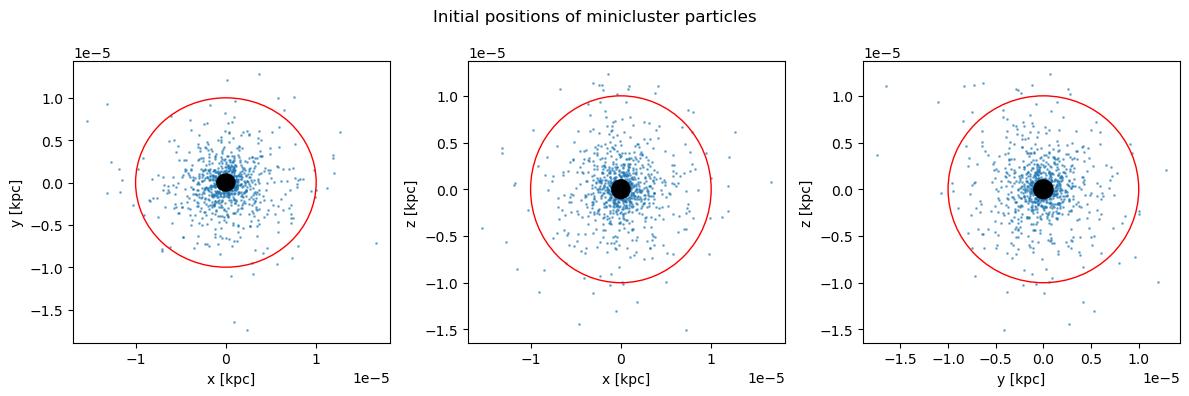

In [57]:
fig,ax=plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Initial positions of minicluster particles')

ax[0].scatter(mcp_xv[:,0], mcp_xv[:,1], s=1, alpha=0.5)
ax[0].set_xlabel('x [kpc]')
ax[0].set_ylabel('y [kpc]')
ax[0].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[0].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))


ax[1].scatter(mcp_xv[:,0], mcp_xv[:,2],s=1, alpha=0.5) 
ax[1].set_xlabel('x [kpc]')
ax[1].set_ylabel('z [kpc]')
ax[1].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[1].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))


ax[2].scatter(mcp_xv[:,1], mcp_xv[:,2],s=1, alpha=0.5)
ax[2].set_xlabel('y [kpc]')
ax[2].set_ylabel('z [kpc]')
ax[2].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[2].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))




plt.tight_layout()
plt.show()

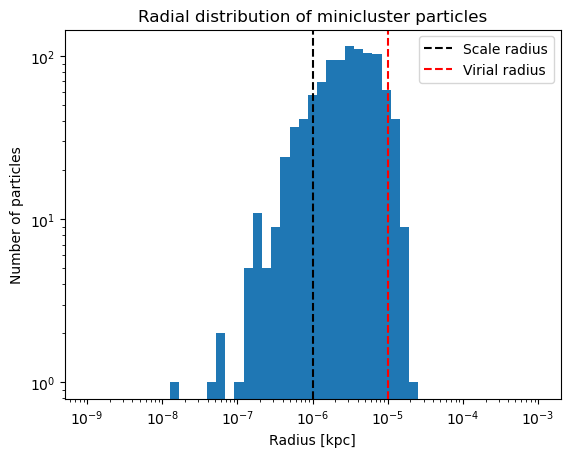

Number of particles within scale radius: 160
Number of particles within virial radius: 777
Number of particles outside virial radius: 63
Total particles: 1000


In [58]:
r_particles = np.linalg.norm(mcp_xv[:, :3], axis=1)
bin=np.logspace(-9,-3,50)
plt.hist(r_particles, bins=bin, log=True)
plt.xlabel('Radius [kpc]')
plt.ylabel('Number of particles')
plt.title('Radial distribution of minicluster particles')
plt.axvline(mc_rs, color='k', linestyle='--', label='Scale radius')
plt.axvline(mc_rvir, color='r', linestyle='--', label='Virial radius')       
plt.xscale('log')
plt.legend()
plt.show()  

print('Number of particles within scale radius:', len(r_particles[r_particles < mc_rs]))
print('Number of particles within virial radius:', len(r_particles[(r_particles < mc_rvir) & (r_particles > mc_rs)]))
print('Number of particles outside virial radius:', len(r_particles[r_particles > mc_rvir]))
print('Total particles:',len(r_particles[r_particles < mc_rs])+len(r_particles[(r_particles < mc_rvir) & (r_particles > mc_rs)])+len(r_particles[r_particles > mc_rvir]))

Text(0, 0.5, 'Number of particles')

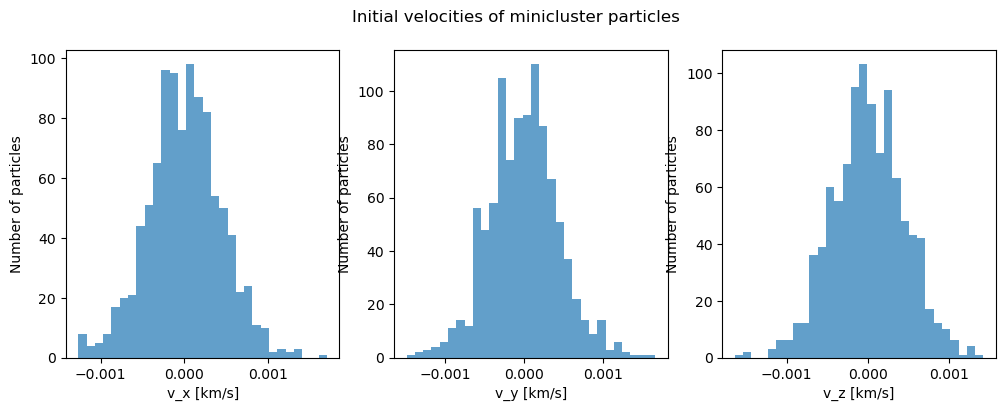

In [59]:
fig,ax=plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Initial velocities of minicluster particles')

ax[0].hist(mcp_xv[:,3], bins=30, alpha=0.7, label='v_x')
ax[0].set_xlabel('v_x [km/s]')
ax[0].set_ylabel('Number of particles')
ax[1].hist(mcp_xv[:,4], bins=30, alpha=0.7, label='v_y')
ax[1].set_xlabel('v_y [km/s]')
ax[1].set_ylabel('Number of particles')
ax[2].hist(mcp_xv[:,5], bins=30, alpha=0.7, label='v_z')
ax[2].set_xlabel('v_z [km/s]')
ax[2].set_ylabel('Number of particles')


In [60]:
solar_pos = np.array([8.0, 0.0, 0.0, 0.0, 0.0, 220.0]) 


In [61]:
N_orbits=1
orbit_time = N_orbits *    pot_mw.Tcirc(solar_pos)


In [62]:
mc_center=reverse_orbit(solar_pos, pot_mw,N_orbits*pot_mw.Tcirc(solar_pos),4, 10)

Starting position: [  4.9225802   0.          0.9293877 -44.18088     0.        327.12216  ]


In [63]:
mcp_xv += mc_center

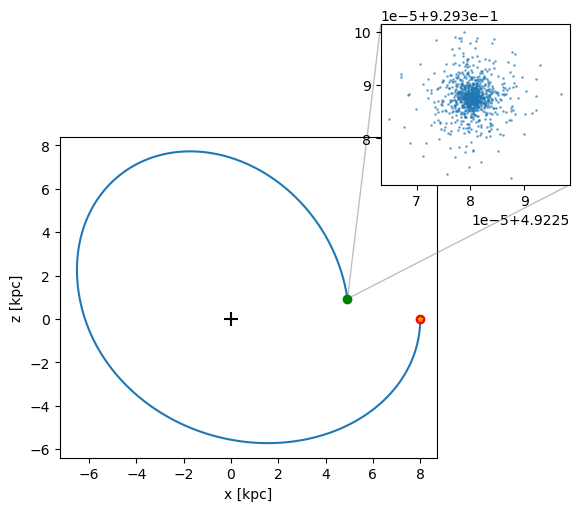

In [64]:
time_test, traj = agama.orbit(ic=mc_center, potential=pot_mw, time=N_orbits*pot_mw.Tcirc(mc_center), trajsize=500)
fig,ax=plt.subplots()
ax.plot(traj[:, 0], traj[:, 2])
ax.scatter(traj[0, 0],  traj[0, 2],  color='g', zorder=5, label='Start')
ax.scatter(traj[-1, 0], traj[-1, 2], color='r', zorder=5, label='End')
ax.scatter(8.0, 0.0, marker='*', s=10, color='yellow', edgecolors='orange', zorder=5, label='Sun')
ax.scatter(0.0, 0.0, marker='+', s=100, color='black', zorder=5, label='Galactic center')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')


ax.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz=ax.inset_axes([0.85, 0.85, 0.5, 0.5])
axz.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)

In [65]:
simulation_time = orbit_time
tupd            = 1e-3 # update interval [Gyr]: CoM step + N-body step

mcp_xv_init    = mcp_xv.copy()
mc_center_init = mc_center.copy()

times_u = [0.0]
mc_mass = [mc_mass0]
mc_traj = [mc_center.copy()]
bound   = np.ones(len(mcp_xv), dtype=bool)  # all particles start bound
time_i  = 0.0

In [66]:

n_steps = round(simulation_time / tupd)

with tqdm(total=n_steps) as pbar:
    while time_i < simulation_time:

        mc_time_center, mc_orbit_center = agama.orbit(ic=mc_center, potential=pot_mw, time=tupd,timestart=time_i, trajsize=100, accuracy=1e-10)
        times_u.append(mc_time_center[-1])
        mc_traj.extend(mc_orbit_center[1:])
        mc_center = mc_orbit_center[-1]

        # --- Advance N-body particles in combined MW + moving cluster potential ---
        pot_total = agama.Potential(
            pot_mw,
            agama.Potential(potential=pot_mc,
                            center=np.column_stack((mc_time_center, mc_orbit_center))))
        mcp_xv = np.vstack(
            agama.orbit(ic=mcp_xv, potential=pot_total,
                        time=tupd, timestart=time_i, trajsize=1, accuracy=1e-10)[:, 1])

        # --- Relative coordinates in cluster rest frame ---
        rel_pos = mcp_xv[:, :3] - mc_center[:3]
        rel_vel = mcp_xv[:, 3:6] - mc_center[3:6]
        pos_f=mcp_xv[:, :3]
        vel_f=mcp_xv[:, 3:6]
        # --- Rebuild cluster potential from bound particles only ---
        n_bound = np.sum(bound)
        if n_bound > 10:
            pot_mc = agama.Potential(
                type='multipole',
                particles=(rel_pos[bound], mcp_mass[bound]),
                symmetry='n', lmax=4)  

        # --- Update bound mask ---
        bound_energy = pot_mc.potential(rel_pos) + 0.5 * np.sum(rel_vel**2, axis=1) < 0
        bound        = bound_energy

        mc_mass.append(np.sum(mcp_mass[bound]))
        time_i += tupd

        pbar.update(1)



  0%|          | 0/163 [00:00<?, ?it/s]

1000 orbits complete (14286 orbits/s)
1000 orbits complete (3067 orbits/s)
1000 orbits complete (3509 orbits/s)
1000 orbits complete (2801 orbits/s)
1000 orbits complete (3472 orbits/s)
1000 orbits complete (2941 orbits/s)
1000 orbits complete (3448 orbits/s)
1000 orbits complete (3704 orbits/s)
1000 orbits complete (3876 orbits/s)
1000 orbits complete (3021 orbits/s)
1000 orbits complete (2865 orbits/s)
1000 orbits complete (2874 orbits/s)
1000 orbits complete (1443 orbits/s)
1000 orbits complete (1883 orbits/s)
1000 orbits complete (3891 orbits/s)
1000 orbits complete (3937 orbits/s)
1000 orbits complete (3774 orbits/s)
1000 orbits complete (2519 orbits/s)
1000 orbits complete (3906 orbits/s)
1000 orbits complete (3968 orbits/s)
1000 orbits complete (3831 orbits/s)
1000 orbits complete (3623 orbits/s)
1000 orbits complete (3802 orbits/s)
1000 orbits complete (3922 orbits/s)
1000 orbits complete (3953 orbits/s)
1000 orbits complete (3968 orbits/s)
1000 orbits complete (3802 orbits/s)


In [26]:
mc_traj = np.array(mc_traj)

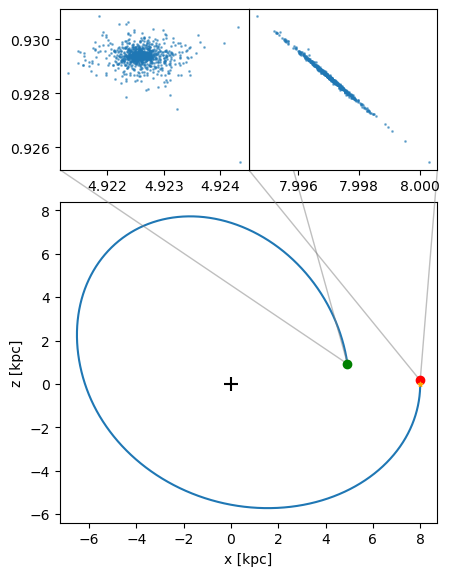

In [27]:
fig,ax=plt.subplots()
ax.plot(mc_traj[:, 0], mc_traj[:, 2])
ax.scatter(mc_traj[0, 0],  mc_traj[0, 2],  color='g', zorder=5, label='Start')
ax.scatter(mc_traj[-1, 0], mc_traj[-1, 2], color='r', zorder=5, label='End')
ax.scatter(8.0, 0.0, marker='*', s=10, color='yellow', edgecolors='orange', zorder=5, label='Sun')
ax.scatter(0.0, 0.0, marker='+', s=100, color='black', zorder=5, label='Galactic center')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')


ax.scatter(pos_f[:,0], pos_f[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz=ax.inset_axes([0.5, 1.1, 0.5, 0.5])
axz.scatter(pos_f[:,0], pos_f[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)

ax.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz2=ax.inset_axes([0, 1.1, 0.5, 0.5])
axz2.scatter(mcp_xv_init[:,0], mcp_xv_init[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz2)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)

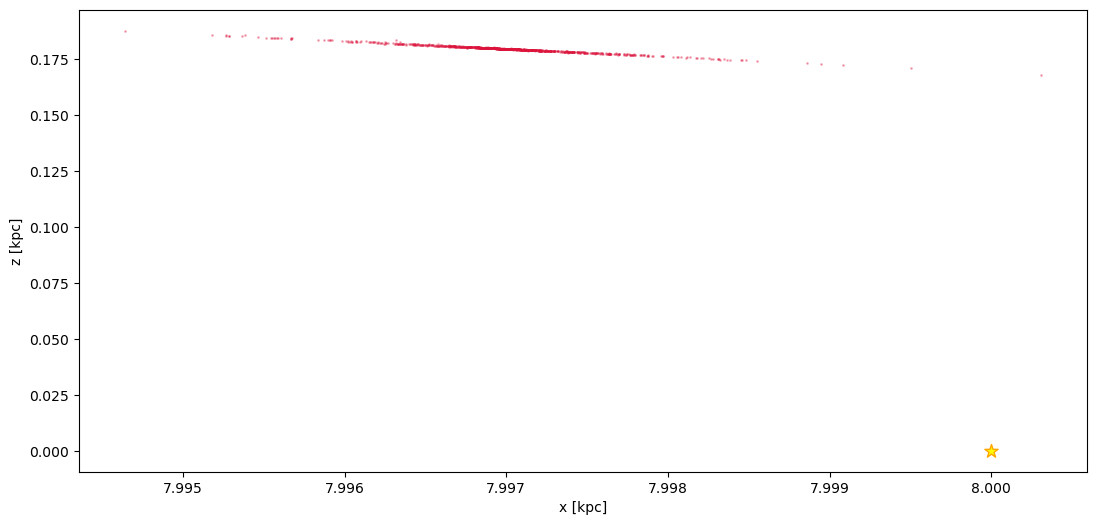

In [21]:


fig, axes = plt.subplots(figsize=(13, 6))


ax = axes
ax.scatter(pos_f[bound,  0], pos_f[bound,  2], s=2,   color='limegreen',label=f'Bound ({bound.sum()})')
ax.scatter(pos_f[~bound, 0], pos_f[~bound, 2], s=1, color='crimson', alpha=0.3,label=f'Unbound ({(~bound).sum()})')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')

plt.scatter(solar_pos[0], solar_pos[2], marker='*', s=100, color='yellow', edgecolors='orange', zorder=5, label='Sun')